# Analyzing Performance of RBF SVM and AdaBoost Machine Learning Models on Varied Linear-Dependency of Features

In [8]:
!pip install ucimlrepo
!pip install shap


In [2]:


# Then, reinstall scikit-learn and a compatible numpy version
!pip install scikit-learn==1.3.2 numpy==1.26.4

import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from sklearn.pipeline import Pipeline
from sklearn.model_selection import StratifiedKFold, GridSearchCV
from sklearn.ensemble import AdaBoostClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.datasets import make_classification
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, confusion_matrix, precision_score, recall_score, f1_score, roc_auc_score, roc_curve
import shap
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import classification_report

In this phase, we imported the Breast Cancer Wisconsin (Diagnostic) dataset from the UCI Machine Learning Repository and combined its characteristics and target labels into a single DataFrame. We renamed the target column **'diagnosis'** to make it easier to deal with. Finally, I exhibited the dataset shape as well as the number of benign (B) and malignant (M) instances to help me comprehend the data before preprocessing and training the models.

In [3]:
from ucimlrepo import fetch_ucirepo
import pandas as pd

# Fetch dataset (id=17 is Breast Cancer Wisconsin Diagnostic)
breast_cancer = fetch_ucirepo(id=17)
X_raw = breast_cancer.data.features
y_raw = breast_cancer.data.targets

# Build a single dataframe with a 'diagnosis' column
df = pd.concat([X_raw, y_raw], axis=1)
df = df.rename(columns={y_raw.columns[0]: 'diagnosis'})

print(df.shape)
print(df['diagnosis'].value_counts())
print("--------------------------Sample of Full Dataset--------------------------------")
print(df.head())

(569, 31)
diagnosis
B    357
M    212
Name: count, dtype: int64
--------------------------Sample of Full Dataset--------------------------------
   radius1  texture1  perimeter1   area1  smoothness1  compactness1  \
0    17.99     10.38      122.80  1001.0      0.11840       0.27760   
1    20.57     17.77      132.90  1326.0      0.08474       0.07864   
2    19.69     21.25      130.00  1203.0      0.10960       0.15990   
3    11.42     20.38       77.58   386.1      0.14250       0.28390   
4    20.29     14.34      135.10  1297.0      0.10030       0.13280   

   concavity1  concave_points1  symmetry1  fractal_dimension1  ...  texture3  \
0      0.3001          0.14710     0.2419             0.07871  ...     17.33   
1      0.0869          0.07017     0.1812             0.05667  ...     23.41   
2      0.1974          0.12790     0.2069             0.05999  ...     25.53   
3      0.2414          0.10520     0.2597             0.09744  ...     26.50   
4      0.1980          0.104

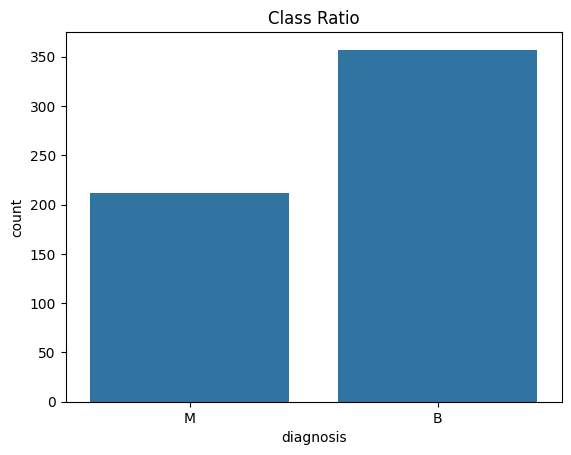

In [4]:
#Visualize class ratio
sns.countplot(x='diagnosis', data=df)
plt.title('Class Ratio')
plt.show()

This class imbalance is considered mild. This set is closer to being balanced then imbalanced.

In [11]:
#Extract the feature names
X_labels_ = X_raw.columns
print(X_labels_)
print(len(X_labels_))

Index(['radius1', 'texture1', 'perimeter1', 'area1', 'smoothness1',
       'compactness1', 'concavity1', 'concave_points1', 'symmetry1',
       'fractal_dimension1', 'radius2', 'texture2', 'perimeter2', 'area2',
       'smoothness2', 'compactness2', 'concavity2', 'concave_points2',
       'symmetry2', 'fractal_dimension2', 'radius3', 'texture3', 'perimeter3',
       'area3', 'smoothness3', 'compactness3', 'concavity3', 'concave_points3',
       'symmetry3', 'fractal_dimension3'],
      dtype='object')
30


In this phase, we imported the Breast Cancer Wisconsin (Diagnostic) dataset from the UCI Machine Learning Repository and combined its characteristics and target labels into a single DataFrame. We renamed the target column **'diagnosis'** to make it easier to deal with. Finally, we exhibited the dataset shape as well as the number of benign (B) and malignant (M) instances to help us comprehend the data before preprocessing and training the models.

In [5]:

# Split Features and Target Labels (X and y)
# We seperate our features (X) and the target variabel (y)
X = df.drop(columns=['diagnosis'])
y = df['diagnosis']


Now that our data has been split and we checked for null values, we will now apply GridSearchCV using Stratified K fold validation to find the best hyper parameters for each of our models.

In [6]:
#Defeine CV
cv_strategy = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

#Define scoring metric
scoring_metric = 'f1' # F1 is used because so the model that has the lowest amount of false negatives would be prioritized


In [7]:
#GridSearch for Decision tree on original data
dt_pipeline = Pipeline([ ('scaler', StandardScaler()), ('dt_org', DecisionTreeClassifier(random_state=42)) ])
dt_mod_090_pipeline = Pipeline([ ('scaler', StandardScaler()), ('dt_mod_090', DecisionTreeClassifier(random_state=42)) ])
dt_mod_model_097_pipeline = Pipeline([ ('scaler', StandardScaler()), ('dt_mod_097', DecisionTreeClassifier(random_state=42)) ])

dt_param_grid = { 'dt_org__criterion': ['gini', 'entropy'],
                 'dt_org__max_depth': [None, 5, 10, 15,],
                  'dt_org__min_samples_split': [2, 5, 10, 20],
                  'dt_org__min_samples_leaf': [1, 2, 4, 10]}


dt_param_grid_mod_090 = { 'dt_mod_090__criterion': ['gini', 'entropy'],
                         'dt_mod_090__max_depth': [None, 5, 10, 15,],
                          'dt_mod_090__min_samples_split': [2, 5, 10, 20],
                          'dt_mod_090__min_samples_leaf': [1, 2, 4, 10]}

dt_param_grid_mod_097 = { 'dt_mod_097__criterion': ['gini', 'entropy'],
                         'dt_mod_097__max_depth': [None, 5, 10, 15,],
                          'dt_mod_097__min_samples_split': [2, 5, 10, 20],
                          'dt_mod_097__min_samples_leaf': [1, 2, 4, 10]}

dt_org_model = GridSearchCV(dt_pipeline, dt_param_grid, cv=cv_strategy, scoring=scoring_metric, n_jobs=-1)
dt_mod_model_090 = GridSearchCV(dt_mod_090_pipeline, dt_param_grid_mod_090, cv=cv_strategy, scoring=scoring_metric, n_jobs=-1)
dt_mod_model_097 = GridSearchCV(dt_mod_model_097_pipeline, dt_param_grid_mod_097, cv=cv_strategy, scoring=scoring_metric, n_jobs=-1)
#_________________________________________________________________________________________________________________

#GridSearch for RBF SVM
rbf_svm_pipeline = Pipeline([ ('scaler', StandardScaler()), ('rbf_svm_org', SVC(kernel='rbf', probability=True, random_state=42)) ])
rbf_svm_pipeline_mod_090 = Pipeline([ ('scaler', StandardScaler()), ('rbf_svm_mod_090', SVC(kernel='rbf', probability=True, random_state=42)) ])
rbf_svm_pipeline_mod_097 = Pipeline([ ('scaler', StandardScaler()), ('rbf_svm_mod_097', SVC(kernel='rbf', probability=True, random_state=42)) ])

rbf_svm_param_grid = { 'rbf_svm_org__C': [0.001, 0.01, 1, 10, 100],
                      'rbf_svm_org__gamma': ['scale', 'auto', 0.01, 0.1],
                       'rbf_svm_org__class_weight': ['balanced', None]}

rbf_svm_param_grid_090 = { 'rbf_svm_mod_090__C': [0.001, 0.01, 1, 10, 100],
                          'rbf_svm_mod_090__gamma': ['scale', 'auto', 0.01, 0.1],
                           'rbf_svm_mod_090__class_weight': ['balanced', None]}

rbf_svm_param_grid_097 = { 'rbf_svm_mod_097__C': [0.001, 0.01, 1, 10, 100],
                          'rbf_svm_mod_097__gamma': ['scale', 'auto', 0.01, 0.1],
                           'rbf_svm_mod_097__class_weight': ['balanced', None]}

rbf_svm_org_model = GridSearchCV(rbf_svm_pipeline, rbf_svm_param_grid, cv=cv_strategy,scoring=scoring_metric, n_jobs=-1)
rbf_svm_mod_model_090 = GridSearchCV(rbf_svm_pipeline_mod_090, rbf_svm_param_grid_090, cv=cv_strategy,scoring=scoring_metric, n_jobs=-1)
rbf_svm_mod_model_097 = GridSearchCV(rbf_svm_pipeline_mod_097, rbf_svm_param_grid_097, cv=cv_strategy,scoring=scoring_metric, n_jobs=-1)

#______________________________________________________________________________________________________________________
#GridSearch for AdaBoost model
ada_boost_pipeline = Pipeline([ ('scaler', StandardScaler()), ('ada_boost_org', AdaBoostClassifier(random_state=42)) ])
ada_boost_pipeline_mod_090 = Pipeline([ ('scaler', StandardScaler()), ('ada_boost_mod_090', AdaBoostClassifier(random_state=42)) ])
ada_boost_pipeline_mod_097 = Pipeline([ ('scaler', StandardScaler()), ('ada_boost_mod_097', AdaBoostClassifier(random_state=42)) ])

ada_boost_param_grid = { 'ada_boost_org__n_estimators': [50, 100, 150, 200, 250],
                        'ada_boost_org__learning_rate': [0.001, 0.01, 0.1, 1, 10]}

ada_boost_param_grid_090 = { 'ada_boost_mod_090__n_estimators': [50, 100, 150, 200, 250],
                            'ada_boost_mod_090__learning_rate': [0.001, 0.01, 0.1, 1, 10]}

ada_boost_param_grid_097 = { 'ada_boost_mod_097__n_estimators': [50, 100, 150, 200, 250],
                            'ada_boost_mod_097__learning_rate': [0.001, 0.01, 0.1, 1, 10]}

ada_boost_org_model = GridSearchCV(ada_boost_pipeline, ada_boost_param_grid, cv=cv_strategy, scoring=scoring_metric, n_jobs=-1)
ada_boost_mod_model_090 = GridSearchCV(ada_boost_pipeline_mod_090, ada_boost_param_grid_090, cv=cv_strategy, scoring=scoring_metric, n_jobs=-1)
ada_boost_mod_model_097 = GridSearchCV(ada_boost_pipeline_mod_097, ada_boost_param_grid_097, cv=cv_strategy, scoring=scoring_metric, n_jobs=-1)

In this preprocessing pipeline, we started by checking for missing values to ensure that the dataset was clean. We then segregated the features from the target variable and divided the data into training and testing sets using an 80/20 split. Finally, we used 'StandardScaler' to normalize the features, which improves the performance of the RBF SVM model and prevents data leaking by only fitting the scaler to training data. This scaled data will be used when computing the correlation matrix

In [8]:
#Verify Data Intergrity (Check for Nulls)
null_sum = X.isnull().sum().sum()
print(f"Data Intergrity Check: There are {null_sum} null values in the feature set.")

Data Intergrity Check: There are 0 null values in the feature set.


We split the data into traininig and test split and apply standard scaler to standardize data for the correlation matrix.

In [9]:
#Train/Test Split
from sklearn.model_selection import train_test_split

# We split the data BEFORE scaling to prevent data leakag.
# Stratify=y ensures the proportion of malignant/benign remains same in both sets.
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
print(f"Training set size: {X_train.shape[0]} samples")
print(f"Training set size: {X_test.shape[0]} samples")

y_train_ = y_train.map({'M': 1, 'B': 0})
y_test_ = y_test.map({'M': 1, 'B': 0})

# Apply Standard Scaler for correlation matrix
from sklearn.preprocessing import StandardScaler

# Initialize the scaler
scaler = StandardScaler()

# Fit on the training set and transform both sets
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)
print("Standard Scaling completed successfully.")


Training set size: 455 samples
Training set size: 114 samples
Standard Scaling completed successfully.


Now, we will generate a correlation matrix on the standarized data, choose a cutoff point, and create an updated matrix with those correlated features removed.

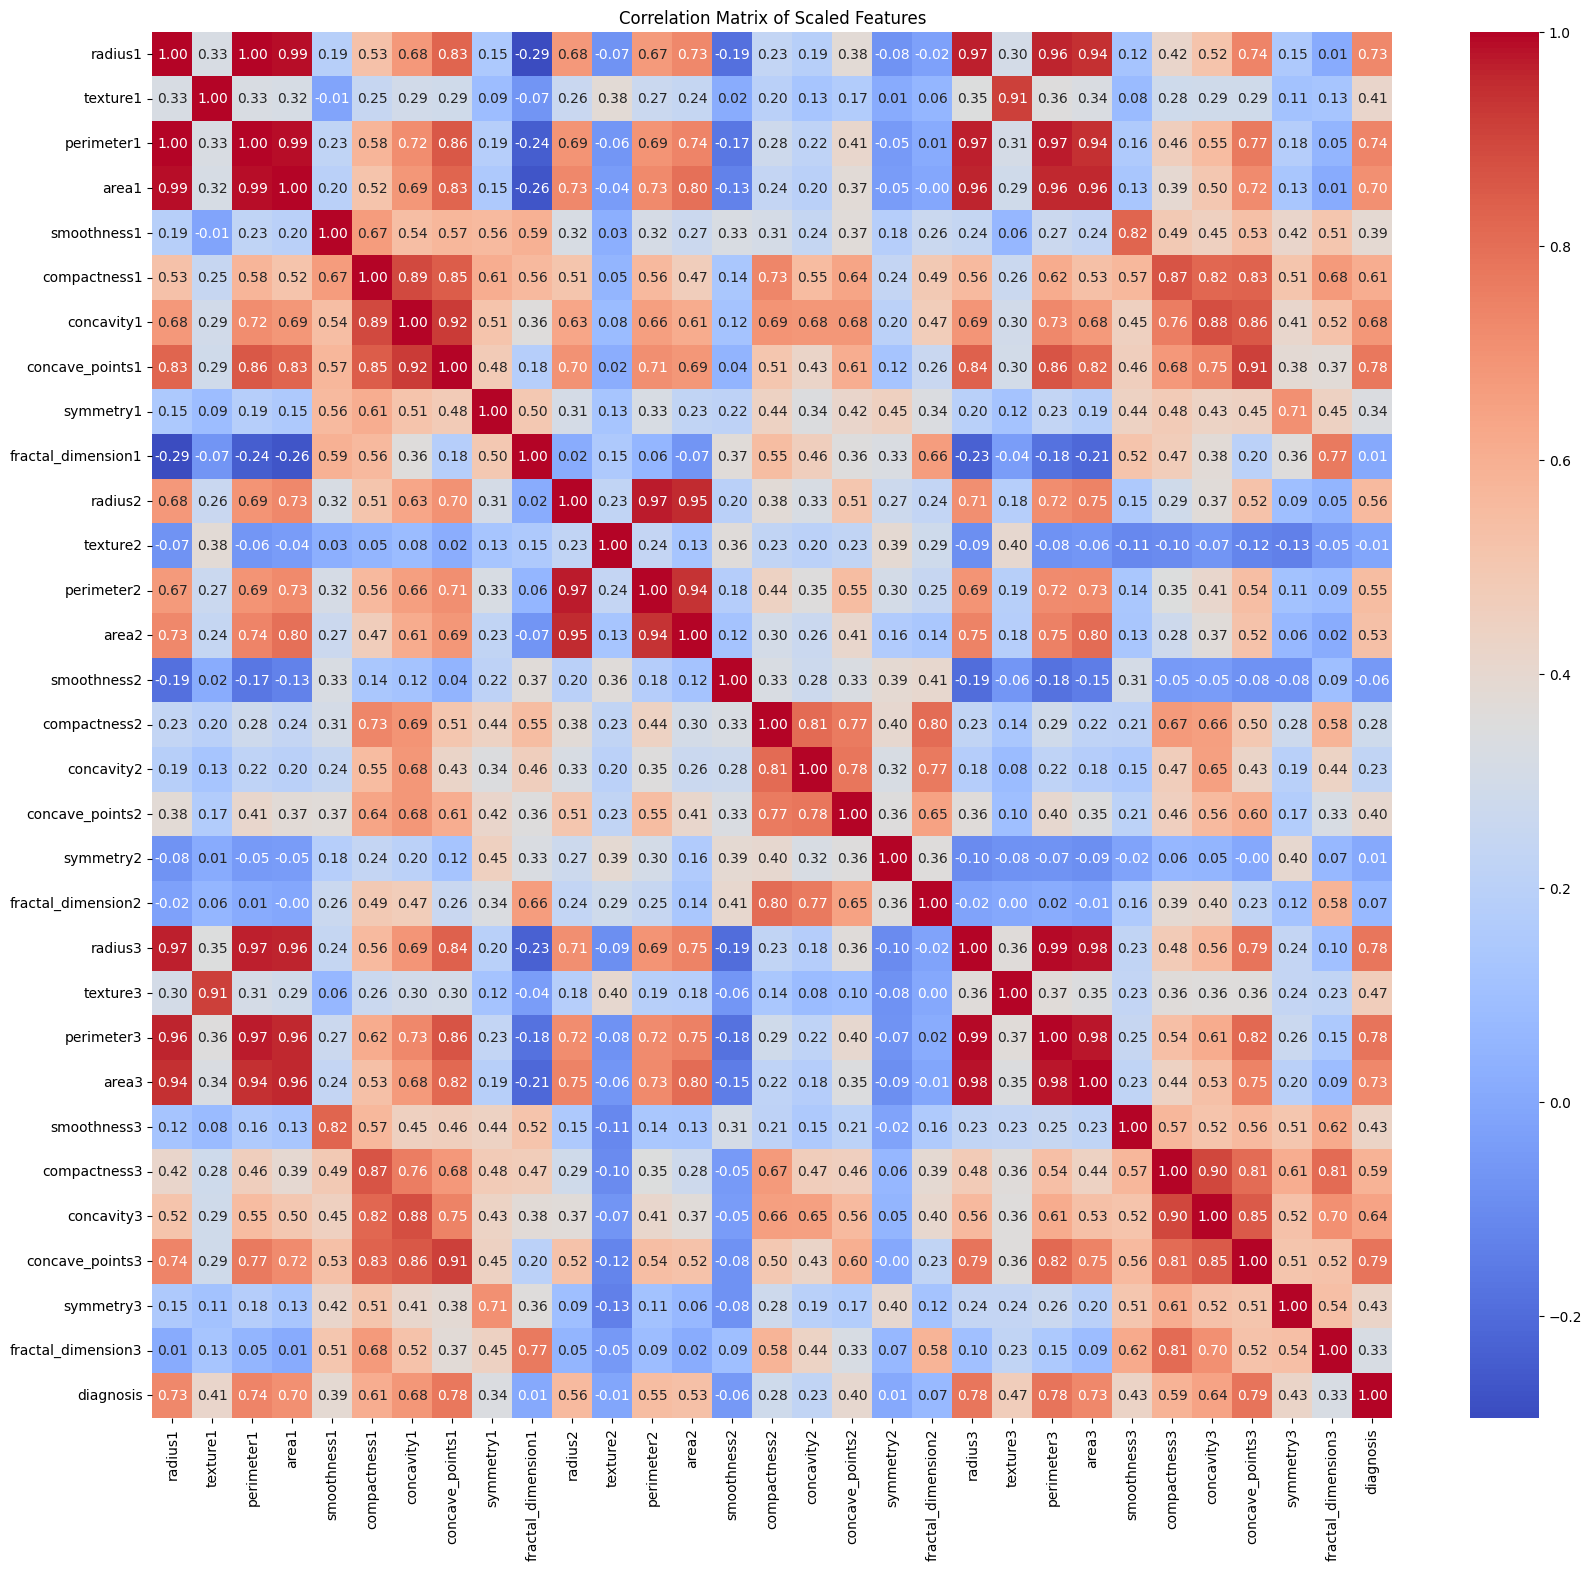

In [12]:
#Generate a correlation matrix

#Encode target values
y_encoded = y_train.map({'M':1, 'B':0})

#Concatenate X values and target values
df_corr = pd.DataFrame(X_train_scaled,columns=X_labels_)
df_corr['diagnosis'] = y_encoded.values

#df_corr_y = pd.concat([df_corr, y_encoded], axis=1)
correlation_matrix = df_corr.corr()

#Visulaize correlation matrix
plt.figure(figsize=(20,18))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Correlation Matrix of Scaled Features')

plt.savefig('correlation_matrix.png')
plt.show()

The closer a correlation value is to 1, the more positively correlated the features are. The closer a correlation value is to -1, the more negatively correlated the features are indicating an inverse relationship. A correlation value of 0 shows little to no correlation.

According to the graph, the below are some that features are highly positively correlated indicating that an increase in one feature would generate an increase in the other:

radius1 and area1 are very highly
radius1 and radius3
radius2 and area2
concavity3 and compactness3
concave_points1 and concave_points3
Moreover, the below features are some that have litte to no correlation:

texture3 and fractal_dimension2
concave_points3 and symmetry2
radius1 and fractal_dimension3

In [13]:
#Create a matrix of scaled x values only to generate abs correlation values
df_x_train_scaled_ = pd.DataFrame(X_train_scaled,columns=X_labels_)
df_x_test_scaled_ = pd.DataFrame(X_test_scaled,columns=X_labels_)
#feature_correlation_matrix = df_x_train_scaled_.corr()

feature_correlation_matrix = df_corr.corr()
abs_corr_matrix = np.abs(feature_correlation_matrix)


#Specify range of cuttoff values
cutoffs = [0.90, 0.97]

#Drop columns that exceed cutoff
i = 0
columns_to_drop = [[],[]] #will hold removed features with correlation weight
for cutoff_value in cutoffs:
  #fill diagonals with 0 for each iteration to get independent results
  full_abs_corr_matrix = abs_corr_matrix.copy()
  np.fill_diagonal(full_abs_corr_matrix.values, 0)
  for col in X_labels_:
    #if col in columns_to_drop:
      #continue
    if full_abs_corr_matrix[col].max() >= cutoff_value:
      row_feature = full_abs_corr_matrix[col].idxmax()
      if row_feature in columns_to_drop[i]: # Check current sublist only
        full_abs_corr_matrix.loc[row_feature, col] = 0
        full_abs_corr_matrix.loc[col, row_feature] = 0
        continue
      if abs_corr_matrix.loc[col, 'diagnosis'] > abs_corr_matrix.loc[row_feature, "diagnosis"]:
        columns_to_drop[i].append(row_feature)
        full_abs_corr_matrix.loc[row_feature, :] = 0
        full_abs_corr_matrix.loc[:, row_feature] = 0
      else:
        columns_to_drop[i].append(col)
        full_abs_corr_matrix.loc[col, :] = 0
        full_abs_corr_matrix.loc[:, col] = 0
  i += 1




#Create a datframe of scaled test features. Used to create an updated test matrix with correlated features removed
df_X_test_scaled_ = pd.DataFrame(X_test_scaled,columns=X_labels_)

#Now create an updated dataset with highly correlated features removed on unscaled data

updated_matrix_x_train_090 = X_train.drop(columns=columns_to_drop[0])
updated_matrix_x_train_090_scaled = df_x_train_scaled_.drop(columns=columns_to_drop[0])
updated_matrix_x_test_090 = X_test.drop(columns=columns_to_drop[0])
updated_matrix_x_test_090_scaled = df_x_test_scaled_.drop(columns=columns_to_drop[0])


updated_matrix_x_train_097 = X_train.drop(columns=columns_to_drop[1])
updated_matrix_x_train_097_scaled = df_x_train_scaled_.drop(columns=columns_to_drop[1])
updated_matrix_x_test_097 = X_test.drop(columns=columns_to_drop[1])
updated_matrix_x_test_097_scaled = df_x_test_scaled_.drop(columns=columns_to_drop[1])

'''
updated_y_train_090 = y_train.drop(columns=columns_to_drop[0])
updated_y_test_090 = y_test.drop(columns=columns_to_drop[0])

updated_y_train_097 = y_train.drop(columns=columns_to_drop[1])
updated_y_test_097 = y_test.drop(columns=columns_to_drop[1])
'''

print(f"Cutoff value {cutoffs[0]}: removed features: {set(columns_to_drop[0])}")
print(f"Shape of updated matrix with 0.90 cutoff: {updated_matrix_x_train_090.shape}")
print("Features removed: ", len(set(columns_to_drop[0])))

print(f"Shape of updated matrix with 0.97 cutoff: {updated_matrix_x_train_097.shape}")
print(f"Cutoff value {cutoffs[1]}: removed features: {set(columns_to_drop[1])}")
print("Features removed: ", len(set(columns_to_drop[1])))



Cutoff value 0.9: removed features: {'concave_points1', 'radius3', 'area2', 'perimeter2', 'radius1', 'area1', 'concavity1', 'area3', 'texture1'}
Shape of updated matrix with 0.90 cutoff: (455, 21)
Features removed:  9
Shape of updated matrix with 0.97 cutoff: (455, 25)
Cutoff value 0.97: removed features: {'radius3', 'perimeter2', 'radius1', 'area1', 'area3'}
Features removed:  5


Now that we have created an updated dataset of correlated features removed, we will use the GridSearch optimal hyperparameters to train our models on both the original dataset and modified.

In [14]:
#Train Decision Tree model, AdaBoost model, and RBF SVM on original data
#First start by fitting each model with GridSearch
dt_org_model.fit(X_train, y_train_)
rbf_svm_org_model.fit(X_train, y_train_)
ada_boost_org_model.fit(X_train, y_train_)

print("Decision tree on original data best params: ", dt_org_model.best_params_)
print("RBF SVM on original data best params: ", rbf_svm_org_model.best_params_)
print("AdaBoost on original data best params: ", ada_boost_org_model.best_params_)

#Generate Predictons for each model on original data
dt_orginal_predictions = dt_org_model.best_estimator_.predict(X_test)
rbf_svm_org_predictions = rbf_svm_org_model.best_estimator_.predict(X_test)
ada_boost_org_predictions = ada_boost_org_model.best_estimator_.predict(X_test)

Decision tree on original data best params:  {'dt_org__criterion': 'entropy', 'dt_org__max_depth': 5, 'dt_org__min_samples_leaf': 2, 'dt_org__min_samples_split': 10}
RBF SVM on original data best params:  {'rbf_svm_org__C': 10, 'rbf_svm_org__class_weight': 'balanced', 'rbf_svm_org__gamma': 0.01}
AdaBoost on original data best params:  {'ada_boost_org__learning_rate': 0.1, 'ada_boost_org__n_estimators': 250}


In [15]:
#Train Decision Tree model, AdaBoost model, and RBF SVM on modified data cutoff 0.90
#First start by fitting each model with GridSearch
dt_mod_model_090.fit(updated_matrix_x_train_090, y_train_ )
rbf_svm_mod_model_090.fit(updated_matrix_x_train_090, y_train_)
ada_boost_mod_model_090.fit(updated_matrix_x_train_090, y_train_)

print("Decision tree on modified data best params: ", dt_mod_model_090.best_params_)
print("Adaboost on modified data best params: ", ada_boost_mod_model_090.best_params_)
print("RBF SVM on modified data best params: ", rbf_svm_mod_model_090.best_params_)

#Generate predictions on modified data with cutoff 0.90
dt_mod_090_predictions = dt_mod_model_090.best_estimator_.predict(updated_matrix_x_test_090)
rbf_svm_mod_090_predicitions = rbf_svm_mod_model_090.best_estimator_.predict(updated_matrix_x_test_090)
ada_boost_mod_090_predictions = ada_boost_mod_model_090.best_estimator_.predict(updated_matrix_x_test_090)

Decision tree on modified data best params:  {'dt_mod_090__criterion': 'gini', 'dt_mod_090__max_depth': None, 'dt_mod_090__min_samples_leaf': 10, 'dt_mod_090__min_samples_split': 2}
Adaboost on modified data best params:  {'ada_boost_mod_090__learning_rate': 1, 'ada_boost_mod_090__n_estimators': 100}
RBF SVM on modified data best params:  {'rbf_svm_mod_090__C': 10, 'rbf_svm_mod_090__class_weight': 'balanced', 'rbf_svm_mod_090__gamma': 0.01}


In [16]:
#Train Decision Tree model, AdaBoost model, and RBF SVM on modified data cutoff 0.97
#First start by fitting each model with GridSearch
dt_mod_model_097.fit(updated_matrix_x_train_097, y_train_)
rbf_svm_mod_model_097.fit(updated_matrix_x_train_097, y_train_)
ada_boost_mod_model_097.fit(updated_matrix_x_train_097, y_train_)

print("Decision tree on modified data best params: ", dt_mod_model_097.best_params_)
print("Adaboost on modified data best params: ", ada_boost_mod_model_097.best_params_)
print("RBF SVM on modified data best params: ", rbf_svm_mod_model_097.best_params_)

#Generate Predictions on updated matrix with cutoff of 0.97
dt_mod_097_predictions = dt_mod_model_097.best_estimator_.predict(updated_matrix_x_test_097)
rbf_svm_mod_097_predictions = rbf_svm_mod_model_097.best_estimator_.predict(updated_matrix_x_test_097)
ada_boost_mod_097_predicitons = ada_boost_mod_model_097.best_estimator_.predict(updated_matrix_x_test_097)

Decision tree on modified data best params:  {'dt_mod_097__criterion': 'entropy', 'dt_mod_097__max_depth': None, 'dt_mod_097__min_samples_leaf': 10, 'dt_mod_097__min_samples_split': 2}
Adaboost on modified data best params:  {'ada_boost_mod_097__learning_rate': 0.1, 'ada_boost_mod_097__n_estimators': 200}
RBF SVM on modified data best params:  {'rbf_svm_mod_097__C': 10, 'rbf_svm_mod_097__class_weight': 'balanced', 'rbf_svm_mod_097__gamma': 0.01}


Now that all models were trained on original and updated data, we will generate performance metrics for each set of models

***DECISION TREE***

In [17]:
print("-----------------------------Classification Report for Decision Tree on Original Data------------------------------")
print(classification_report(y_test_, dt_orginal_predictions, target_names=['Benign', 'Malignant']))
#print("")

-----------------------------Classification Report for Decision Tree on Original Data------------------------------
              precision    recall  f1-score   support

      Benign       0.95      1.00      0.97        72
   Malignant       1.00      0.90      0.95        42

    accuracy                           0.96       114
   macro avg       0.97      0.95      0.96       114
weighted avg       0.97      0.96      0.96       114



In [18]:
print("-----------------------------Classification Report for Decision Tree on Modified Data on 0.90------------------------------")
print(classification_report(
    y_test_,
    dt_mod_090_predictions,
    target_names=['Benign', 'Malignant']
))


-----------------------------Classification Report for Decision Tree on Modified Data on 0.90------------------------------
              precision    recall  f1-score   support

      Benign       0.90      0.97      0.93        72
   Malignant       0.94      0.81      0.87        42

    accuracy                           0.91       114
   macro avg       0.92      0.89      0.90       114
weighted avg       0.91      0.91      0.91       114



In [19]:
print("-----------------------------Classification Report for Decision Tree on Modified Data on 0.97------------------------------")
print(classification_report(
    y_test_,
    dt_mod_097_predictions,
    target_names=['Benign', 'Malignant']
))

-----------------------------Classification Report for Decision Tree on Modified Data on 0.97------------------------------
              precision    recall  f1-score   support

      Benign       0.95      1.00      0.97        72
   Malignant       1.00      0.90      0.95        42

    accuracy                           0.96       114
   macro avg       0.97      0.95      0.96       114
weighted avg       0.97      0.96      0.96       114



***ADABOOST***

In [20]:
print("-----------------------------Classification Report for AdaBoost on Original Data------------------------------")
print(classification_report(y_test_, ada_boost_org_predictions,
                            target_names=['Benign', 'Malignant']))


-----------------------------Classification Report for AdaBoost on Original Data------------------------------
              precision    recall  f1-score   support

      Benign       0.96      1.00      0.98        72
   Malignant       1.00      0.93      0.96        42

    accuracy                           0.97       114
   macro avg       0.98      0.96      0.97       114
weighted avg       0.97      0.97      0.97       114



In [21]:
print("-----------------------------Classification Report for AdaBoost on Modified Data on .90------------------------------")
print(classification_report(y_test_, ada_boost_mod_090_predictions,
                            target_names=['Benign', 'Malignant']))

-----------------------------Classification Report for AdaBoost on Modified Data on .90------------------------------
              precision    recall  f1-score   support

      Benign       0.97      0.99      0.98        72
   Malignant       0.98      0.95      0.96        42

    accuracy                           0.97       114
   macro avg       0.97      0.97      0.97       114
weighted avg       0.97      0.97      0.97       114



In [22]:
print("-----------------------------Classification Report for AdaBoost on Modified Data on .97------------------------------")
print(classification_report(y_test_, ada_boost_mod_097_predicitons,
                            target_names=['Benign', 'Malignant']))



-----------------------------Classification Report for AdaBoost on Modified Data on .97------------------------------
              precision    recall  f1-score   support

      Benign       0.96      1.00      0.98        72
   Malignant       1.00      0.93      0.96        42

    accuracy                           0.97       114
   macro avg       0.98      0.96      0.97       114
weighted avg       0.97      0.97      0.97       114



***RBF SVM***

In [23]:
print("-----------------------------Classification Report for RBF SVM on Original Data------------------------------")
print(classification_report(y_test_, rbf_svm_org_predictions,
                            target_names=['Benign', 'Malignant']))


-----------------------------Classification Report for RBF SVM on Original Data------------------------------
              precision    recall  f1-score   support

      Benign       0.99      1.00      0.99        72
   Malignant       1.00      0.98      0.99        42

    accuracy                           0.99       114
   macro avg       0.99      0.99      0.99       114
weighted avg       0.99      0.99      0.99       114



In [24]:
print("-----------------------------Classification Report for RBF SVM on Modified Data------------------------------")
print(classification_report(y_test_, rbf_svm_mod_090_predicitions,
                            target_names=['Benign', 'Malignant']))

-----------------------------Classification Report for RBF SVM on Modified Data------------------------------
              precision    recall  f1-score   support

      Benign       0.97      1.00      0.99        72
   Malignant       1.00      0.95      0.98        42

    accuracy                           0.98       114
   macro avg       0.99      0.98      0.98       114
weighted avg       0.98      0.98      0.98       114



In [ ]:
print("-----------------------------Classification Report for RBF SVM on Modified Data------------------------------")
print(classification_report(y_test_, rbf_svm_mod_097_predictions,
                            target_names=['Benign', 'Malignant']))



-----------------------------Classification Report for RBF SVM on Modified Data------------------------------
              precision    recall  f1-score   support

      Benign       0.97      1.00      0.99        72
   Malignant       1.00      0.95      0.98        42

    accuracy                           0.98       114
   macro avg       0.99      0.98      0.98       114
weighted avg       0.98      0.98      0.98       114



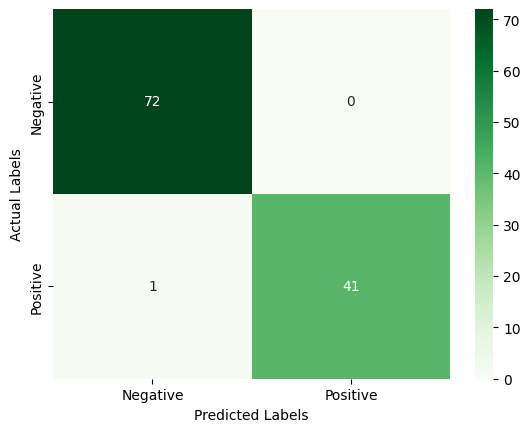

In [25]:
#matrix_dt = confusion_matrix(y_test_, rbf_svm_org_predictions, labels=[0, 1])
#print(matrix_dt)

matrix_dt = confusion_matrix(y_test_, rbf_svm_org_predictions)

# Build the plot
sns.heatmap(matrix_dt, annot=True, fmt='d', cmap='Greens',
            xticklabels=['Negative', 'Positive'],
            yticklabels=['Negative', 'Positive'])

plt.ylabel('Actual Labels')
plt.xlabel('Predicted Labels')
plt.show()

We see that the RBF SVM has a small amount of false negatives.

Here we generate SHAP values for baseline model on all configurations of data as well as on best performing adaboost and rbf svm.

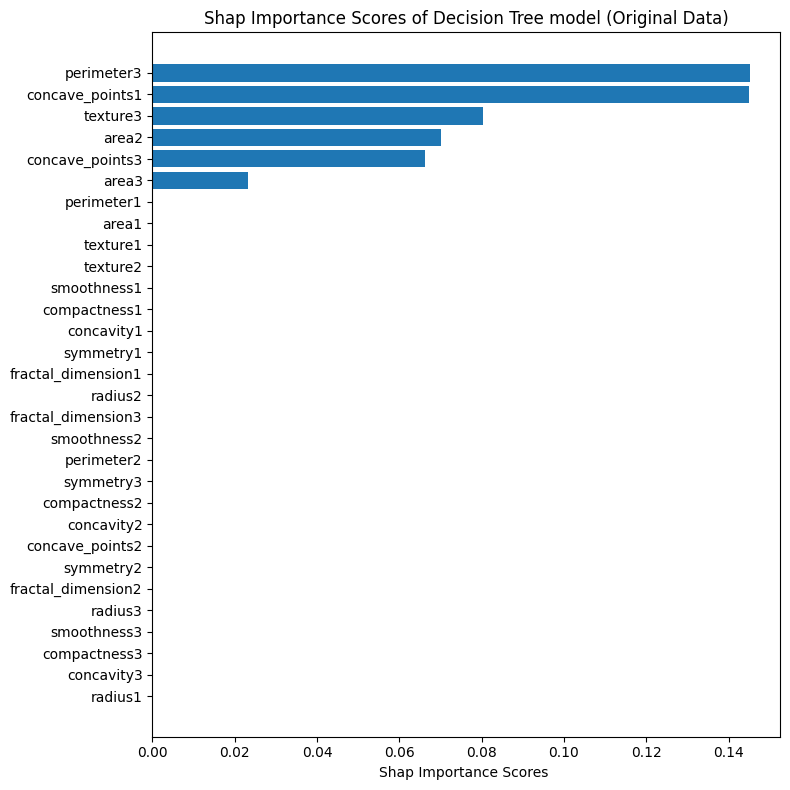

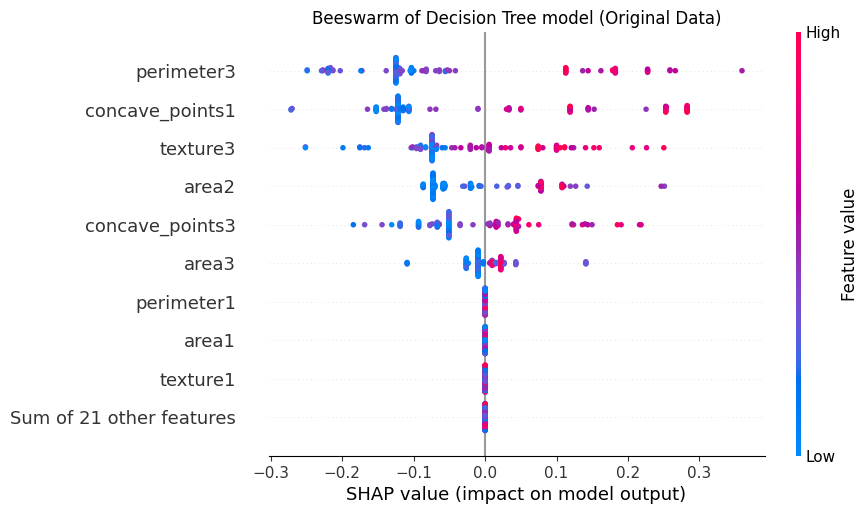

In [26]:
#Shap explainer for Decision tree classifier with both orignal and modified dataset
dtc_shap_explainer_org = shap.Explainer(dt_org_model.best_estimator_['dt_org'], X_train_scaled)
dtc_shap_values_org = dtc_shap_explainer_org(X_test_scaled)

#Visualize feature importance
dtc_shap_values_org_class1 = dtc_shap_values_org[:,:,1]
dtc_shap_values_org_class1.feature_names = list(X_labels_)

#raw_shap_org = dtc_shap_values_org.values[:,:, 1] # get raw fearure imporance scores for malignant class
abs_value_raw_shap_org = np.abs(dtc_shap_values_org_class1.values)
mean_of_features = np.mean(abs_value_raw_shap_org, axis=0)
feature_chart = {'Feature': X_labels_, 'Shap Importance Scores': mean_of_features} # create a dictionary that correlates feature to average shap feature importance
feature_chart_ = pd.DataFrame(feature_chart)
sorted_feature_chart = feature_chart_.sort_values(by='Shap Importance Scores', ascending=True)

#Create a graph
plt.figure(figsize=(8,8))
plt.barh(sorted_feature_chart['Feature'], sorted_feature_chart['Shap Importance Scores'])
plt.xlabel("Shap Importance Scores ")
plt.title("Shap Importance Scores of Decision Tree model (Original Data)")
plt.tight_layout()
plt.savefig('shap_dtc_org', bbox_inches='tight', dpi=300)
plt.show()

shap.plots.beeswarm(dtc_shap_values_org_class1, show=False)
plt.title("Beeswarm of Decision Tree model (Original Data)")
plt.savefig('beeswarm_shap_dtc_org',  bbox_inches='tight', dpi=300)
plt.show()

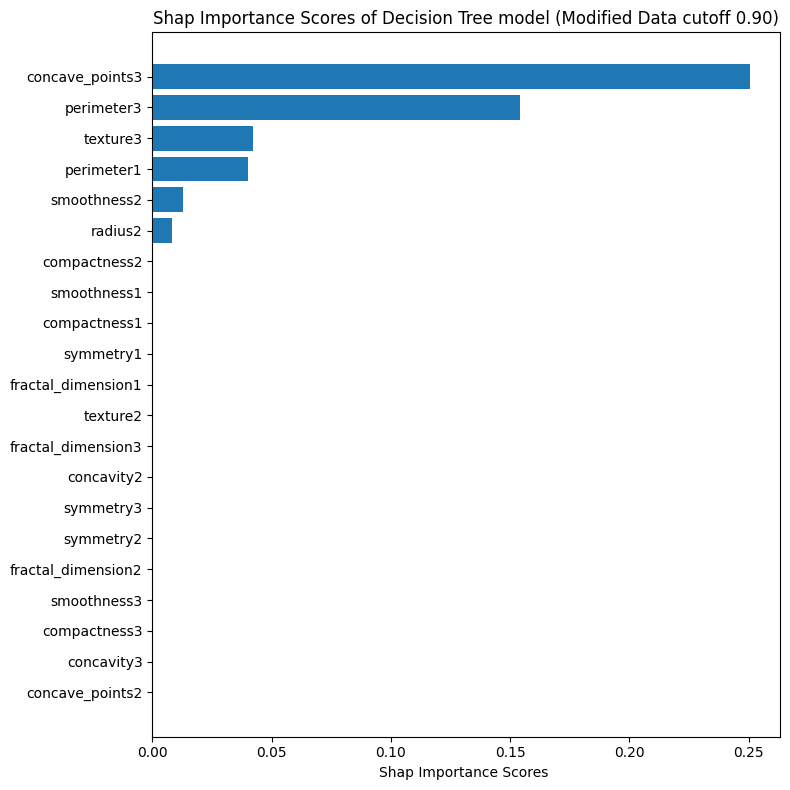

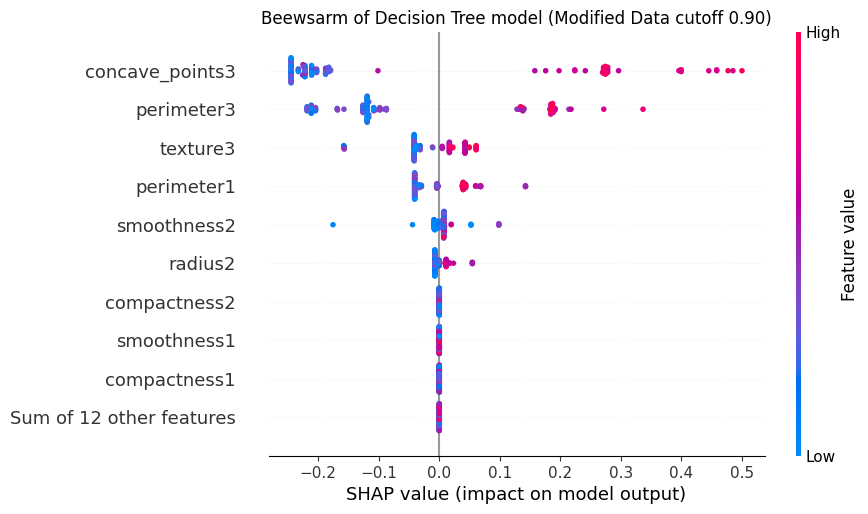

In [27]:
#Shap explainer for Decision tree classifier with modified dataset 0.90 cutoff
dtc_shap_explainer_mod_090 = shap.Explainer(dt_mod_model_090.best_estimator_['dt_mod_090'], updated_matrix_x_train_090_scaled)
dtc_shap_values_mod_090 = dtc_shap_explainer_mod_090(updated_matrix_x_test_090_scaled)

#Visualize feature importance
dtc_shap_values_mod_090_class1 = dtc_shap_values_mod_090[:,:,1]
dtc_shap_values_mod_090_class1.feature_names = list(updated_matrix_x_train_090.columns)

#raw_shap_org = dtc_shap_values_org.values[:,:, 1] # get raw fearure imporance scores for malignant class
abs_value_raw_shap_mod_090 = np.abs(dtc_shap_values_mod_090_class1.values)
mean_of_features_mod_dtc_090 = np.mean(abs_value_raw_shap_mod_090, axis=0)
feature_chart_mod_dtc_090 = {'Feature': updated_matrix_x_train_090.columns, 'Shap Importance Scores': mean_of_features_mod_dtc_090} # create a dictionary that correlates feature to average shap feature importance
feature_chart_mod_dtc_090_ = pd.DataFrame(feature_chart_mod_dtc_090)
sorted_feature_chart_mod_090 = feature_chart_mod_dtc_090_.sort_values(by='Shap Importance Scores', ascending=True)

#Create a graph
plt.figure(figsize=(8,8))
plt.barh(sorted_feature_chart_mod_090['Feature'], sorted_feature_chart_mod_090['Shap Importance Scores'])
plt.xlabel("Shap Importance Scores ")
plt.title("Shap Importance Scores of Decision Tree model (Modified Data cutoff 0.90)")
plt.tight_layout()
plt.savefig('shap_dtc_mod_90')
plt.show()

shap.plots.beeswarm(dtc_shap_values_mod_090_class1, show=False)
plt.title("Beewsarm of Decision Tree model (Modified Data cutoff 0.90)")
plt.savefig('beeswarm_shap_dtc_mod_090')
plt.show()

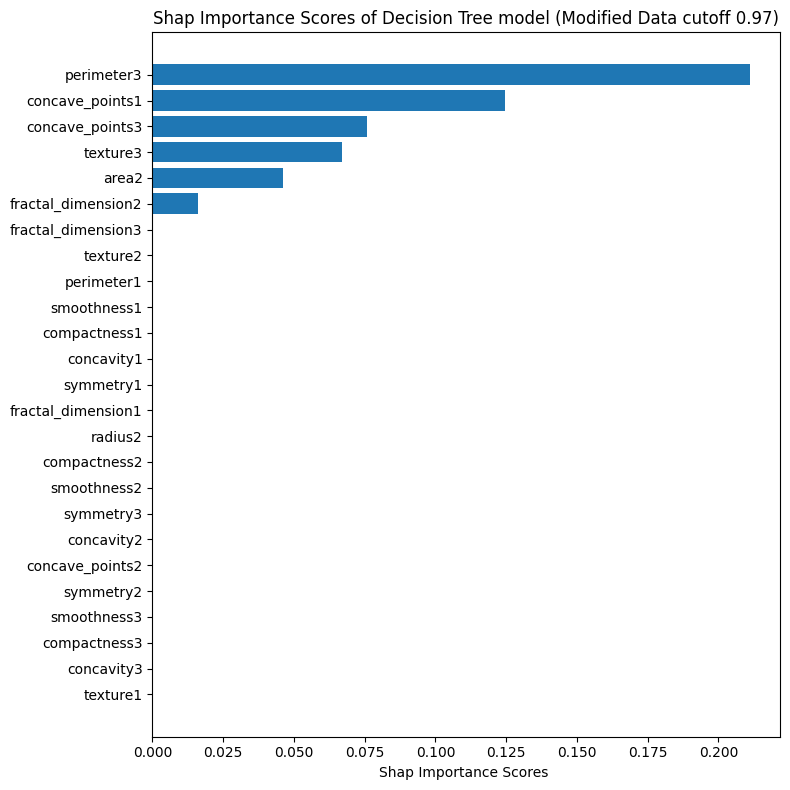

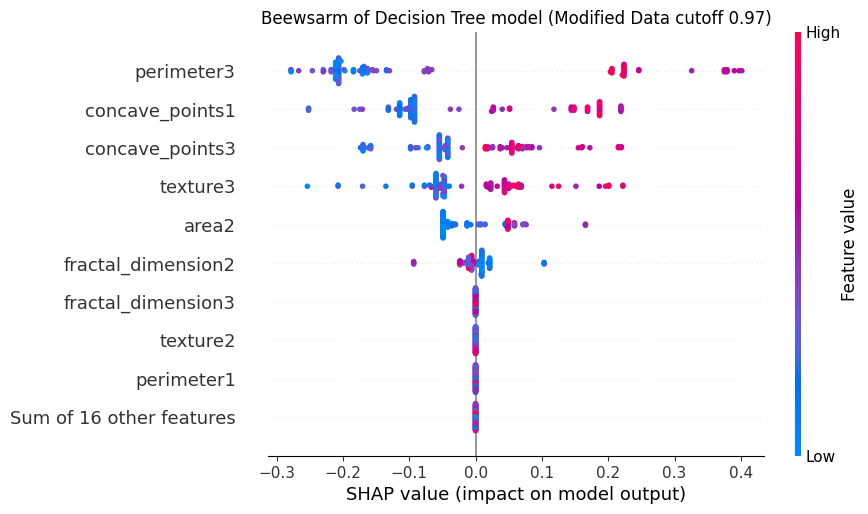

In [28]:
#Shap explainer for Decision tree classifier with modified dataset 0.97 cutoff
dtc_shap_explainer_mod_097 = shap.Explainer(dt_mod_model_097.best_estimator_['dt_mod_097'], updated_matrix_x_train_097_scaled)
dtc_shap_values_mod_097 = dtc_shap_explainer_mod_097(updated_matrix_x_test_097_scaled)

#Visualize feature importance
dtc_shap_values_mod_097_class1 = dtc_shap_values_mod_097[:,:,1]
dtc_shap_values_mod_097_class1.feature_names = list(updated_matrix_x_train_097.columns)

#raw_shap_org = dtc_shap_values_org.values[:,:, 1] # get raw fearure imporance scores for malignant class
abs_value_raw_shap_mod_097 = np.abs(dtc_shap_values_mod_097_class1.values)
mean_of_features_mod_dtc_097 = np.mean(abs_value_raw_shap_mod_097, axis=0)
feature_chart_mod_dtc_097 = {'Feature': updated_matrix_x_train_097.columns, 'Shap Importance Scores': mean_of_features_mod_dtc_097} # create a dictionary that correlates feature to average shap feature importance
feature_chart_mod_dtc_097_ = pd.DataFrame(feature_chart_mod_dtc_097)
sorted_feature_chart_mod_097 = feature_chart_mod_dtc_097_.sort_values(by='Shap Importance Scores', ascending=True)

#Create a graph
plt.figure(figsize=(8,8))
plt.barh(sorted_feature_chart_mod_097['Feature'], sorted_feature_chart_mod_097['Shap Importance Scores'])
plt.xlabel("Shap Importance Scores ")
plt.title("Shap Importance Scores of Decision Tree model (Modified Data cutoff 0.97)")
plt.tight_layout()
plt.savefig('shap_dtc_mod_97')
plt.show()

shap.plots.beeswarm(dtc_shap_values_mod_097_class1, show= False)
plt.title("Beewsarm of Decision Tree model (Modified Data cutoff 0.97)")
plt.savefig('beeswarm_shap_dtc_mod_097')
plt.show()

PermutationExplainer explainer: 115it [04:37,  2.45s/it]


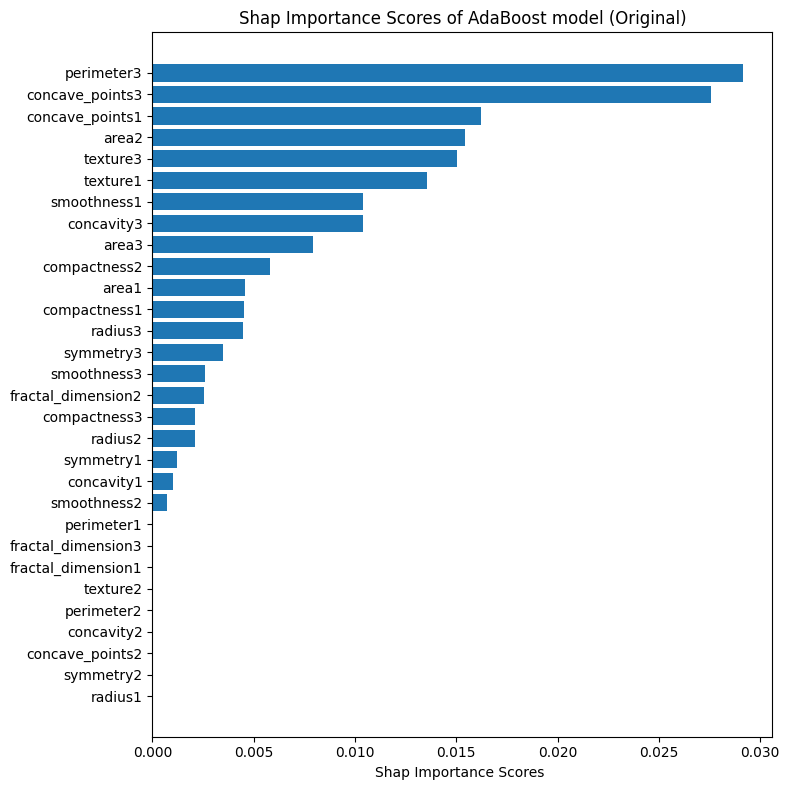

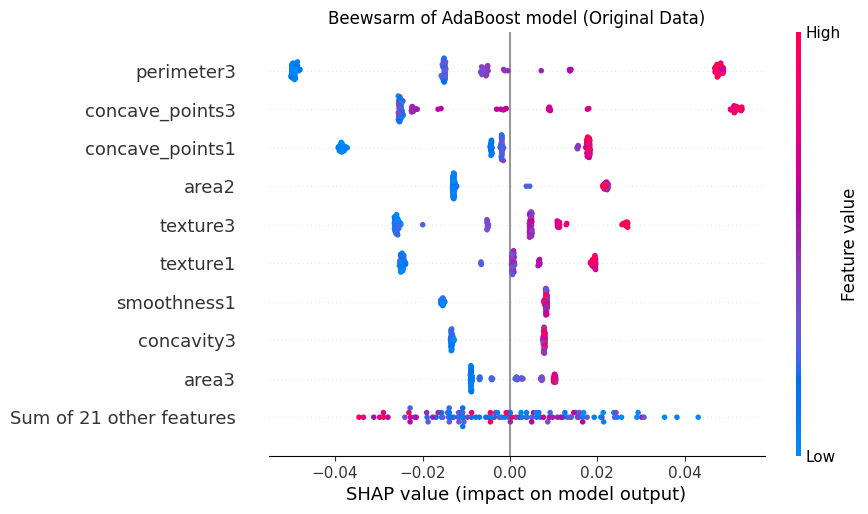

In [29]:
#Shap explainer for AdaBoost model with origial dataset
ada_dtc_shap_explainer_org = shap.Explainer(ada_boost_org_model.best_estimator_['ada_boost_org'].predict_proba, X_train_scaled)
ada_dtc_shap_values_org = ada_dtc_shap_explainer_org(X_test_scaled)

#Visualize feature importance
ada_dtc_shap_values_org_class1 = ada_dtc_shap_values_org[:,:,1]
ada_dtc_shap_values_org_class1.feature_names = list(X_labels_)

#raw_shap_org = dtc_shap_values_org.values[:,:, 1] # get raw fearure imporance scores for malignant class
abs_value_raw_shap_mod_dtc = np.abs(ada_dtc_shap_values_org_class1.values)
mean_of_features_ada_dtc_org = np.mean(abs_value_raw_shap_mod_dtc, axis=0)
feature_chart_ada_dtc_org = {'Feature': X_labels_, 'Shap Importance Scores': mean_of_features_ada_dtc_org} # create a dictionary that correlates feature to average shap feature importance
feature_chart_ada_dtc_org_ = pd.DataFrame(feature_chart_ada_dtc_org)
sorted_feature_chart_ada_dtc_org_ = feature_chart_ada_dtc_org_.sort_values(by='Shap Importance Scores', ascending=True)

#Create a graph
plt.figure(figsize=(8,8))
plt.barh(sorted_feature_chart_ada_dtc_org_['Feature'], sorted_feature_chart_ada_dtc_org_['Shap Importance Scores'])
plt.xlabel("Shap Importance Scores ")
plt.title("Shap Importance Scores of AdaBoost model (Original)")
plt.tight_layout()
plt.savefig('shap_ada_dtc_org')
plt.show()

shap.plots.beeswarm(ada_dtc_shap_values_org_class1, show=False)
plt.title("Beewsarm of AdaBoost model (Original Data)")
plt.savefig('beeswarm_shap_ada_dtc_org')
plt.show()

In [ ]:
#Shap explainer for AdaBoost model with Modified dataset with 0.90 cutoff
ada_dtc_shap_explainer_mod_090 = shap.Explainer(ada_boost_mod_model_090.best_estimator_.predict_proba, updated_matrix_x_train_090_scaled)
ada_dtc_shap_values_mod_090 = ada_dtc_shap_explainer_mod_090(updated_matrix_x_test_090_scaled)
#Visualize feature importance
ada_dtc_shap_values_mod_class1_090 = ada_dtc_shap_values_mod_090[:,:,1]
ada_dtc_shap_values_mod_class1_090.feature_names = list(updated_matrix_x_train_090_scaled.columns)
#raw_shap_org = dtc_shap_values_org.values[:,:, 1] # get raw fearure imporance scores for malignant class
abs_value_raw_shap_mod_dtc_090 = np.abs(ada_dtc_shap_values_mod_class1_090.values)
mean_of_features_ada_dtc_mod_090 = np.mean(abs_value_raw_shap_mod_dtc_090, axis=0)
feature_chart_ada_dtc_mod_090 = {'Feature': updated_matrix_x_train_090_scaled.columns, 'Shap Importance Scores': mean_of_features_ada_dtc_mod_090} # create a dictionary that correlates feature to average shap feature importance
feature_chart_ada_dtc_mod_090_ = pd.DataFrame(feature_chart_ada_dtc_mod_090)
sorted_feature_chart_ada_dtc_mod_090 = feature_chart_ada_dtc_mod_090_.sort_values(by='Shap Importance Scores', ascending=True)
#Create a graph
plt.figure(figsize=(8,8))
plt.barh(sorted_feature_chart_ada_dtc_mod_090['Feature'], sorted_feature_chart_ada_dtc_mod_090['Shap Importance Scores'])
plt.xlabel("Shap Importance Scores ")
plt.title("Shap Importance Scores of AdaBoost model (Modified Data with cutoff 0.90)")
plt.tight_layout()
plt.savefig('shap_dtc_org')
plt.show()

shap.plots.beeswarm(ada_dtc_shap_values_mod_class1_090, show=False)
plt.title("Beewsarm of AdaBoost model (Modified Data with cutoff 0.90)")
plt.savefig('daBoost_model_090')
plt.show()

PermutationExplainer explainer:  45%|████▍     | 51/114 [00:44<00:52,  1.21it/s]

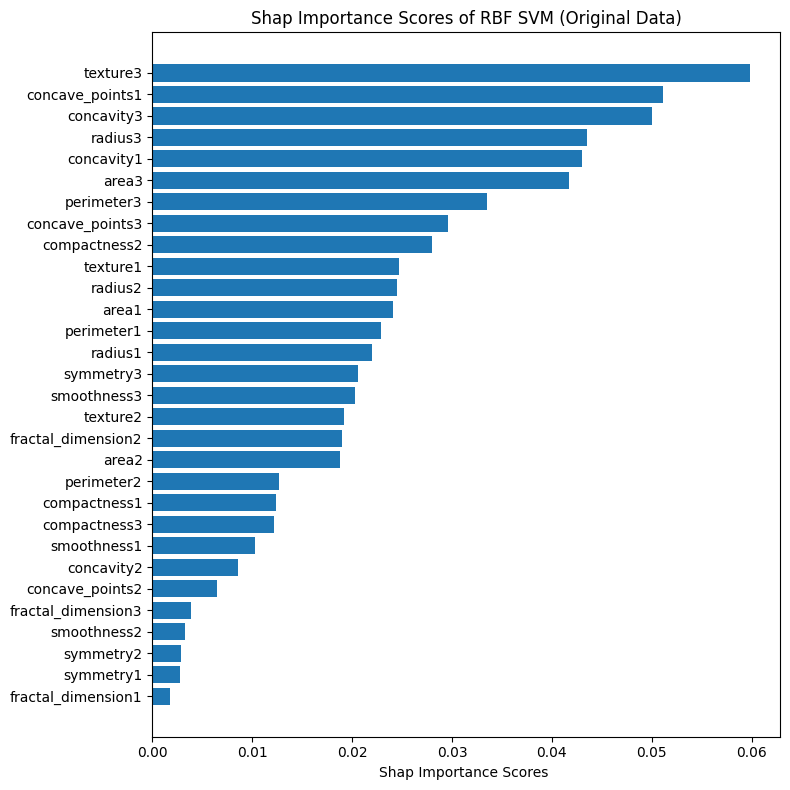

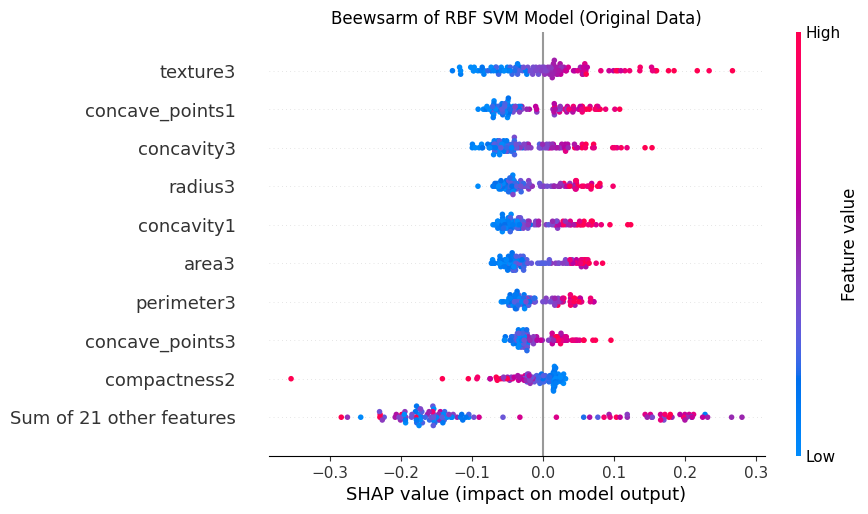

In [ ]:
import matplotlib.pyplot as plt

#Generate Shap Scores on RBF SVM model (original data)
rbf_svm_shap_explainer_org = shap.Explainer(rbf_svm_org_model.best_estimator_['rbf_svm_org'].predict_proba, shap.sample(X_train_scaled, 10))
rbf_svm_shap_values_org = rbf_svm_shap_explainer_org(X_test_scaled)

rbf_svm_shap_values_org_class1 = rbf_svm_shap_values_org[:,:,1] #extract shap values for malignant class
rbf_svm_shap_values_org_class1.feature_names = list(X_labels_)

#Visualize feature importance as bar graph
#raw_shap_rbf_svm = rbf_svm_shap_values_org.values[:,:, 1] # get raw fearure imporance scores for malignant class
abs_value_raw_shap_rbf_svm = np.abs(rbf_svm_shap_values_org_class1.values)
mean_of_features_rbf_svm = np.mean(abs_value_raw_shap_rbf_svm, axis=0)
feature_chart_rbf_svm = {'Feature': X_labels_, 'Shap Importance Scores': mean_of_features_rbf_svm} # create a dictionary that correlates feature to average shap feature importance
feature_chart_rbf_svm_ = pd.DataFrame(feature_chart_rbf_svm)
sorted_feature_chart_rbf_svm_ = feature_chart_rbf_svm_.sort_values(by='Shap Importance Scores', ascending=True)

#Create a graph
plt.figure(figsize=(8,8))
plt.barh(sorted_feature_chart_rbf_svm_['Feature'], sorted_feature_chart_rbf_svm_['Shap Importance Scores'])
plt.xlabel("Shap Importance Scores ")
plt.title("Shap Importance Scores of RBF SVM (Original Data)")
plt.tight_layout()
plt.show()



plt.title("Beewsarm of RBF SVM Model (Original Data)")
shap.plots.beeswarm(rbf_svm_shap_values_org_class1)